# Define the seeds

In [9]:
import random
import os
import numpy as np

pi_digit_string = "1415926535897932384626433832795028841971"
seeds= [int(pi_digit_string[i:i+2]) for i in range(0, len(pi_digit_string), 2)]
print(len(seeds), seeds)

def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

# Set the seed for reproducibility
set_seed(seeds[0])

20 [14, 15, 92, 65, 35, 89, 79, 32, 38, 46, 26, 43, 38, 32, 79, 50, 28, 84, 19, 71]


# Process data that has been augmented and normalized

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import sys
sys.path.append("../preprocessing")
from augmenter import Augmenter, augment_rf_data 

# Load full combined dataset
df = pd.read_csv("../preprocessing/ready/squat_dataset_handcrafted.csv")

# Split into features and labels
feature_cols = [col for col in df.columns if col != "label"]
X = df[feature_cols].values  
y = df["label"].values 

# Train/test split
X_train_raw, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seeds[0] 
)

# --- Inspect a sample BEFORE normalization ---
print("\n First training sample (raw):")
print(X_train_raw[0])

# Normalize using only training data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)  # Normalize training data
X_test = scaler.transform(X_test)

# Augment only the training set
augmenter = Augmenter(noise_std=0.05, noise_n=2)  # Now suitable for normalized data
X_train, y_train = augment_rf_data(X_train, y_train, augmenter, base_seed=seeds[0])

# --- Inspect a few augmented versions of the sample ---
print("\n First training sample after augmentation (original + 2 augmented versions):")
print("Original (normalized):")
print(X_train[0])
print("Augmented version 1:")
print(X_train[1])
print("Augmented version 2:")
print(X_train[2])

# Final stats
print(f"\n Loaded and split: {len(X_train)} training samples, {len(X_test)} test samples")
print(f" Using {len(feature_cols)} features")




 First training sample (raw):
[ 8.28057480e-02  4.79693635e-03  2.48162381e+01  9.84951678e+00
  1.04210579e+01  4.00508591e+01  8.38828681e-01  1.78177845e-01
  6.04683559e-01  1.12848298e+00  1.51766408e+02  2.93231230e+01
  8.39662065e+01  1.73060270e+02 -9.72351464e-02  6.47505595e-02
 -1.59518540e-01  2.25291252e-02  1.40282807e+02  4.26444643e+01
  5.62620915e+01  1.78150037e+02]

 First training sample after augmentation (original + 2 augmented versions):
Original (normalized):
[0.21706648 0.20170121 0.1496469  0.21646535 0.27816087 0.18001226
 0.5599616  0.20928726 0.6641258  0.07481878 0.6458691  0.43335062
 0.41767037 0.35106692 0.71272516 0.7362834  0.6649865  0.8149743
 0.40782192 0.7073382  0.24112263 0.66066337]
Augmented version 1:
[0.20068392 0.3248879  0.15425806 0.16506214 0.26970372 0.25451785
 0.6309338  0.31735927 0.6997149  0.1369548  0.6931125  0.3736824
 0.397419   0.35064024 0.67519504 0.7861444  0.585778   0.7477117
 0.51558155 0.6989442  0.3476232  0.6681803

# Preparing the original dataset

In [10]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Load full combined dataset
df = pd.read_csv("../preprocessing/ready/squat_dataset_handcrafted.csv")

# Split into features and labels
feature_cols = [col for col in df.columns if col != "label"]
X = df[feature_cols]
y = df["label"]

# Train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seeds[0]
)

print(f" Loaded and split: {len(X_train)} training samples, {len(X_test)} test samples")
print(f" Using {len(feature_cols)} features")

 Loaded and split: 201 training samples, 51 test samples
 Using 22 features


# Cross-Validation with Best Parameters Logging

In [11]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import math
import time

# start timer
start_time = time.time()
print(f"\n\n--- Grid Search for Random Forest ---")

# Define your hyperparameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [
        int(math.sqrt(X_train.shape[1])),
        int(2 * math.sqrt(X_train.shape[1])),
        int(3 * math.sqrt(X_train.shape[1])),
        None
    ],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
}

# 5-fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seeds[0])

# Initialize model
rf = RandomForestClassifier(random_state=seeds[0])

# Run Grid Search CV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Print best results
print(f"\n Best Parameters: {grid_search.best_params_}")
print(f" Best Cross-Validated Accuracy: {grid_search.best_score_:.4f}")

# View top results
results_df = pd.DataFrame(grid_search.cv_results_).sort_values(by="mean_test_score", ascending=False)
print(results_df[["mean_test_score", "std_test_score", "params"]].head())

# end timer and print elapsed time in minutes
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nElapsed time: {elapsed_time / 60:.2f} minutes")



--- Grid Search for Random Forest ---
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

 Best Parameters: {'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
 Best Cross-Validated Accuracy: 0.9701
     mean_test_score  std_test_score  \
163         0.970122        0.010064   
109         0.970122        0.010064   
82          0.970122        0.010064   
190         0.970122        0.010064   
271         0.970122        0.010064   

                                                params  
163  {'max_depth': 14, 'max_features': 'sqrt', 'min...  
109  {'max_depth': 9, 'max_features': 'log2', 'min_...  
82   {'max_depth': 9, 'max_features': 'sqrt', 'min_...  
190  {'max_depth': 14, 'max_features': 'log2', 'min...  
271  {'max_depth': None, 'max_features': 'log2', 'm...  

Elapsed time: 8.65 minutes


#  Evaluate the Model

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from collections import defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
import json

best_params = {
        'max_depth': 9,
        'max_features': 'sqrt',
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'n_estimators': 300
    }

# Store metrics
results = defaultdict(list)

# Evaluate on multiple test splits using different seeds
for seed in seeds:
    print(f"\n Evaluating with test split from seed {seed}")
    set_seed(seed)

    # Resplit data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )

    # Normalize using only training data
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)  # Normalize training data
    X_test = scaler.transform(X_test)

    # Augment only the training set
    #augmenter = Augmenter(noise_std=0.05, noise_n=2)  # Now suitable for normalized data
    #X_train, y_train = augment_rf_data(X_train, y_train, augmenter, base_seed=seed)
    

    best_rf = RandomForestClassifier(**best_params, random_state=seed)
    best_rf.fit(X_train, y_train)

    # Predict labels and probabilities
    y_pred = best_rf.predict(X_test)
    y_proba = best_rf.predict_proba(X_test)[:, 1]

    # Compute metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Store standard metrics
    results["accuracy"].append(report["accuracy"])
    results["precision"].append(report["1"]["precision"])
    results["recall"].append(report["1"]["recall"])
    results["f1"].append(report["1"]["f1-score"])
    results["roc_auc"].append(roc_auc)

    # Store confusion matrix components
    results["tp"].append(cm[1, 1])
    results["fn"].append(cm[1, 0])
    results["fp"].append(cm[0, 1])
    results["tn"].append(cm[0, 0])

#  Summary
print("\n Final evaluation over multiple test splits:")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    values = results[metric]
    print(f"{metric.capitalize():<10}: {np.mean(values):.4f} ± {np.std(values):.4f}")

#  Average Confusion Matrix
avg_cm = np.array([
    [np.mean(results["tn"]), np.mean(results["fp"])],
    [np.mean(results["fn"]), np.mean(results["tp"])]
]).round().astype(int)

print("\n Mean Confusion Matrix (rounded):")
print(avg_cm)

# Save results to disk for later statistical testing
with open("rf_biomech_accuracy.json", "w") as f:
    json.dump(results["accuracy"], f)


 Evaluating with test split from seed 14

 Evaluating with test split from seed 15

 Evaluating with test split from seed 92

 Evaluating with test split from seed 65

 Evaluating with test split from seed 35

 Evaluating with test split from seed 89

 Evaluating with test split from seed 79

 Evaluating with test split from seed 32

 Evaluating with test split from seed 38

 Evaluating with test split from seed 46

 Evaluating with test split from seed 26

 Evaluating with test split from seed 43

 Evaluating with test split from seed 38

 Evaluating with test split from seed 32

 Evaluating with test split from seed 79

 Evaluating with test split from seed 50

 Evaluating with test split from seed 28

 Evaluating with test split from seed 84

 Evaluating with test split from seed 19

 Evaluating with test split from seed 71

 Final evaluation over multiple test splits:
Accuracy  : 0.9686 ± 0.0235
Precision : 0.9737 ± 0.0393
Recall    : 0.9640 ± 0.0307
F1        : 0.9681 ± 0.0234
Ro

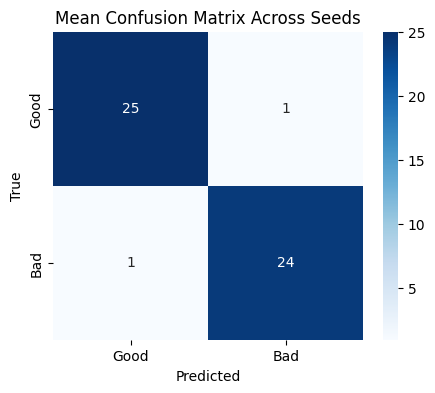

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
sns.heatmap(avg_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Mean Confusion Matrix Across Seeds")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0.5, 1.5], ["Good", "Bad"])
plt.yticks([0.5, 1.5], ["Good", "Bad"])
plt.show()

# SHAP

Seed 14
SHAP values shape: (51, 22, 2)
SHAP values for class 0 shape: (51, 22)
Seed 15
SHAP values shape: (51, 22, 2)
SHAP values for class 0 shape: (51, 22)
Seed 92
SHAP values shape: (51, 22, 2)
SHAP values for class 0 shape: (51, 22)
Seed 65
SHAP values shape: (51, 22, 2)
SHAP values for class 0 shape: (51, 22)
Seed 35
SHAP values shape: (51, 22, 2)
SHAP values for class 0 shape: (51, 22)
Seed 89
SHAP values shape: (51, 22, 2)
SHAP values for class 0 shape: (51, 22)
Seed 79
SHAP values shape: (51, 22, 2)
SHAP values for class 0 shape: (51, 22)
Seed 32
SHAP values shape: (51, 22, 2)
SHAP values for class 0 shape: (51, 22)
Seed 38
SHAP values shape: (51, 22, 2)
SHAP values for class 0 shape: (51, 22)
Seed 46
SHAP values shape: (51, 22, 2)
SHAP values for class 0 shape: (51, 22)
Seed 26
SHAP values shape: (51, 22, 2)
SHAP values for class 0 shape: (51, 22)
Seed 43
SHAP values shape: (51, 22, 2)
SHAP values for class 0 shape: (51, 22)
Seed 38
SHAP values shape: (51, 22, 2)
SHAP values f

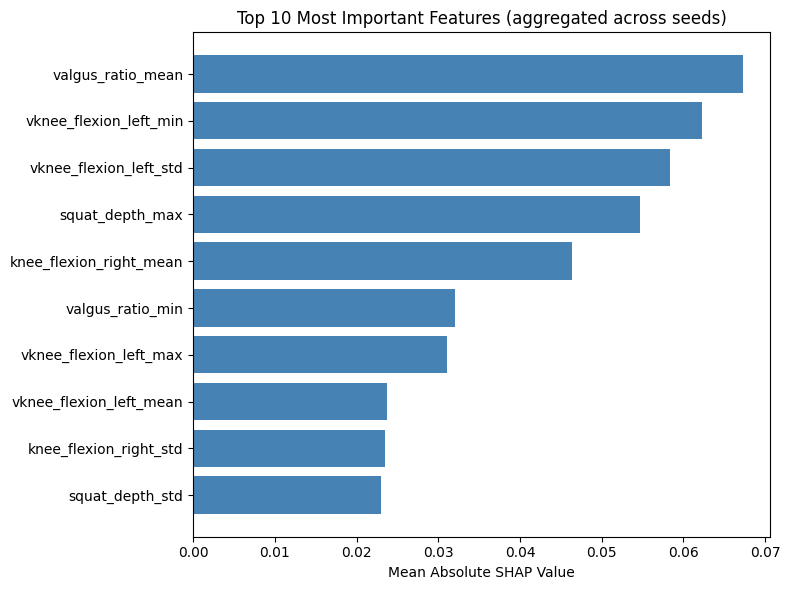

In [69]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


best_params =  {
    'max_depth': 6,
    'max_features': 'sqrt',
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 300
    }


all_shap_values = []
all_X_tests = []

for seed in seeds:
    print(f"Seed {seed}")
    set_seed(seed)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )

    # Normalize
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Augment
    augmenter = Augmenter(noise_std=0.05, noise_n=2)
    X_train, y_train = augment_rf_data(X_train, y_train, augmenter, base_seed=seed)

    # Train model
    model = RandomForestClassifier(**best_params, random_state=seed)
    model.fit(X_train, y_train)

    # Compute SHAP
    explainer = shap.TreeExplainer(model, model_output="raw")

    shap_vals = explainer.shap_values(X_test)  # shape: (n_samples, n_features, 2)

    print(f"SHAP values shape: {shap_vals.shape}")

    # Use class 0 (bad squat) explanation
    shap_vals_class0 = shap_vals[:, :, 1]  # shape: (51, 22)
 # shape: (n_samples, n_features)

    print(f"SHAP values for class 0 shape: {shap_vals_class0.shape}")

    all_shap_values.append(shap_vals_class0)
    all_X_tests.append(X_test)

# Combine all SHAP and test data
shap_all = np.vstack(all_shap_values)
X_test_all = np.vstack(all_X_tests)
# Compute mean absolute SHAP values
mean_abs_shap = np.abs(shap_all).mean(axis=0)

# Ensure feature names match the number of features
feature_names = feature_cols[:shap_all.shape[1]]

print("Shape of shap_all:", shap_all.shape)         # Should be (total_samples, 22)
print("Feature count:", len(feature_cols))          # Should be 22
print("Feature names in plot:", feature_names)      # Should match the above


# Create DataFrame and plot
shap_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP|": mean_abs_shap
}).sort_values(by="Mean |SHAP|", ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(shap_df["Feature"][::-1], shap_df["Mean |SHAP|"][::-1], color="steelblue")
plt.xlabel("Mean Absolute SHAP Value")
plt.title("Top 10 Most Important Features (aggregated across seeds)")
plt.tight_layout()
plt.show()
